## Overview

In this document, I analyze how preprocessing decisions and TF-IDF hyperparameters directly impact the ability of LSA to compress information.

Herein I:
1. Download and preprocess a news corpus (from the 20 Newsgroups dataset built into scikit-learn)
2. Create a baseline TF-IDF vectorization using raw corpus documents with no tokenization pre-processing and the default parameters (no vocabulary filters)
3. Apply LSA (Truncated SVD) and measure explained variance
4. Implement three optimization variations with different preprocessing strategies, notably:
    * *Variation I*: tokenizer function applied, lemmatized, stopwords removed and only Noun and Verbs kept
    * *Variation II*: no tokenizer function and only TfidfVectorizer min and max settings used
    * *Variation III*: both tokenizer function and TfidfVectorizer min and max settings
5. Compare how each variation affects the quality of dimensionality reduction
6. Analyze which "noise" words are removed by strict preprocessing


In [35]:
import random

import numpy as np
import pandas as pd

import spacy

from sklearn import datasets
from sklearn import decomposition
from sklearn.feature_extraction import text

In [36]:
# Random Seed
seed = 42
# Load the SpaCy small Language Model
nlp = spacy.load("en_core_web_sm")

Five categories are selected from the 20 Newsgroups dataset, each from a distinct domain to maximize semantic separability in the LSA space: two sports categories (`rec.sport.baseball`, `rec.sport.hockey`), one science category (`sci.space`), one technology category (`sci.electronics`), and one politics category (`talk.politics.misc`). The two sports categories are intentionally included as they are both within the common `SPORTS` domain, thus, they will be semantically more similar. Thus, they present a harder disambiguation challenge and serve as a useful test of how well the preprocessing strategies preserve fine-grained distinctions.

In [37]:

categories = [
    "rec.sport.baseball",
    "rec.sport.hockey",
    "sci.space",
    "sci.electronics",
    "talk.politics.misc"
]

# fetch_20newsgroups() methods gets the dataset(s) from the sklearn library
newsgroups = datasets.fetch_20newsgroups(
    subset="train",
    categories=categories,
    remove=("headers", "footers", "quotes")
)

corpus = newsgroups.data

f"Loaded {len(corpus)} documents from 5 categories."

'Loaded 2846 documents from 5 categories.'

---

## Baseline Pipeline: Minimal Preprocessing

Below I create a baseline by applying TF-IDF vectorization with minimal text cleaning, then LSA is applied to reduce dimensionality.

For this I:
- Use raw documents with **no spaCy preprocessing**
- Create a document-term matrix from the raw documents using `TfidfVectorizer` with default parameters (no vocabulary filters)
- Apply `TruncatedSVD` with 100 components to store the model and resulting matrix in unique variables.
- Record the **cumulative explained variance** (sum of `explained_variance_ratio_`)

In [38]:
# Create a document-term matrix from the raw documents.

# use 'text' as module namespace for 'TfidfVectorizer()' class
tfidf_vec = text.TfidfVectorizer()
# create sparse matrix from tfidf_vec
tfidf_sparse_matrix = tfidf_vec.fit_transform(corpus)

In [39]:
# Inspect matrix size

# Gets the token names that go with the TF-IDF scores
# Inventory of vocabulary used
token_names = tfidf_vec.get_feature_names_out()

# Create df, applies token names as column headers.
# matrix is already rows, convert to array (matrix.array())
tfidf_df_base = pd.DataFrame(
    tfidf_sparse_matrix.toarray(),
    columns=token_names
)
tfidf_df_base.shape

(2846, 29691)

In [40]:
# Apply TruncatedSVD to the TF-IDF matrix with 100 components, store model and resulting matrix in unique variables

# Get LSA explained-variance score
# 'decomposition' as namespace, module, TruncatedSVD() is class
svd = decomposition.TruncatedSVD(n_components=100, random_state=42)
# stores the tfidf_sparse_matrix model and resulting matrix in unique variables in svd
# -> populates 'svd'!!
truncated_svd_matrix = svd.fit_transform(tfidf_sparse_matrix)

In [41]:
# Display the cumulative explained variance (sum of all explained_variance_ratio_ values)

# can use just pd.DataFrame() because truncated_svd_matrix is already np.array
truncated_svd_df = pd.DataFrame(truncated_svd_matrix)
# get .sum() of variance from populated 'svd'..
svd.explained_variance_ratio_.sum()

np.float64(0.18631501714231366)

---

## Variation I: Strict spaCy Preprocessing

In this variation, strict text cleaning using spaCy is applied **before** vectorization:
- stopwords removed
- lemmatization applied
- only **NOUN** and **VERB** part-of-speech tags kept

After preprocessing,`TfidfVectorizer` and `TruncatedSVD` configuration applied as with as the baseline.

In [42]:
# Tokenizer function

from typing import List # make type hint python 3.8 compatible

# parameter "text" comes from whatever calls the function
# "text" name arbitrary, could be changed
def spacy_tokenizer(text: str) -> list[str]:
  doc = nlp(text)
   # set inclusion "token.pos_ in {"NOUN","VERB"}"
  tokenized = [token.text for token in doc if token.is_alpha
                and token.pos_ in {"NOUN", "VERB"}
                and not token.is_stop]
  return tokenized

In [43]:
# Apply TfidfVectorizer with default parameters is applied to the preprocessed documents

# i. Creates TF-IDF vectorizer object (unpopulated)
# ii. feeds 'text' to the param for spacy_tokenizer
tfidf_vec_v1 = text.TfidfVectorizer(tokenizer=spacy_tokenizer)
# i. calls tokenizer func
# ii. builds vocab
# iii. computes doc freq, tf-idf weights
# iv. converts wach doc to tf-idf vector
# v. stacks docs into one matrix
tfidf_sparse_matrix_v1 = tfidf_vec_v1.fit_transform(corpus)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [44]:
# returns the ordered list of feature names (tokens / n-grams)
#...that became the columns of your matrix.
token_names_v1 = tfidf_vec_v1.get_feature_names_out()

tfidf_vec_v1_df = pd.DataFrame(
    tfidf_sparse_matrix_v1.toarray(),
    columns=token_names_v1
)
# test the shape of matrix
tfidf_vec_v1_df.shape

(2846, 18164)

In [45]:
# Apply TruncatedSVD to the TF-IDF matrix with 100 components, and the model and resulting matrix are stored in unique variables

# Get LSA explained-variance score
# 'decomposition' as namespace, module, TruncatedSVD() is class
# creates an empty object w/ params
svd_v1 = decomposition.TruncatedSVD(n_components=100, random_state=42)
# populates 'svd' object, stores the tfidf_sparse_matrix model and resulting matrix in unique variables in svd
# fit_transform()
truncated_svd_matrix_v1 = svd_v1.fit_transform(tfidf_sparse_matrix_v1)

In [46]:
# Display the cumulative explained variance which is (sum of all explained_variance_ratio_ values).

# can use just pd.DataFrame() because truncated_svd_matrix is already np.array
truncated_svd_v1_df = pd.DataFrame(truncated_svd_matrix_v1)
# get sum of variance from populated svd..
svd_v1.explained_variance_ratio_.sum()

np.float64(0.17320817148769999)

---

## Variation II: TF-IDF Vocabulary Pruning

In this variation, **raw documents** (no spaCy preprocessing) are used in combination with the built-in vocabulary filters in `TfidfVectorizer` using the parameters:
* `min_df` of 5 (tokens must be found
in at least 5 documents)
* `max_df` of 0.7 (token cannot be found in more than 70% of documents)

In [47]:
# min_df=5 (minimum found in 5 documents) max_df=0.7 (max found in 70% of documents)
tfidf_vec_v2 = text.TfidfVectorizer(min_df=5, max_df=0.7)
tfidf_sparse_matrix_v2 = tfidf_vec_v2.fit_transform(corpus)

In [48]:
# Returns the ordered list of feature names (tokens / n-grams)
#...that became the columns of your matrix.
token_names_v2 = tfidf_vec_v2.get_feature_names_out()
# count_sparse_matrix is a sparse matrix (efficient storage for..
# mostly-zero data). Counts of each feature (above) in each doc
tfidf_vec_v2_df = pd.DataFrame(
    tfidf_sparse_matrix_v2.toarray(),
    columns=token_names_v2
)
# Print matrix shape to show the number of docs and features (vocabulary size)
tfidf_vec_v2_df.shape

(2846, 6984)

In [49]:
# Apply TruncatedSVD to the TF-IDF matrix with 100 components

# always used imported "decomposition" as the stem to .TruncatedSVD()
svd_v2 = decomposition.TruncatedSVD(n_components=100, random_state=42)
truncated_svd_matrix_v2 = svd_v2.fit_transform(tfidf_sparse_matrix_v2)

In [50]:
# Display the cumulative explained variance (sum of variance from populated svd..)
svd_v2.explained_variance_ratio_.sum()

np.float64(0.2184206536676407)

---

## Variation III: Combined Optimization

In this variation, **both** preprocessing strategies are combined:

Herein I:
- Use the spaCy-preprocessed documents from Variation I
- Apply TF-IDF vocabulary pruning with `min_df` and `max_df`, using the same values as chosen for Variation II

This represents the most aggressive noise reduction strategy of the three variants.

In [51]:
#  TfidfVectorizer with min_df and max_df on the spaCy-preprocessed documents.
tfidf_vec_v3 = text.TfidfVectorizer(tokenizer=spacy_tokenizer, min_df=5, max_df=0.7)
tfidf_sparse_matrix_v3 = tfidf_vec_v3.fit_transform(corpus)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [52]:
# returns the ordered list of feature names (tokens / n-grams)
#...that became the columns of your matrix.
token_names_v3 = tfidf_vec_v3.get_feature_names_out()

# count_sparse_matrix is a sparse matrix (efficient storage for..
# mostly-zero data). Counts of each feature (above) in each doc

tfidf_vec_v3_df = pd.DataFrame(
    tfidf_sparse_matrix_v3.toarray(),
    columns=token_names_v3
)
# Display the shape of matrix showing the number of documents and features (i.e. vocabulary size)
tfidf_vec_v3_df.shape

(2846, 4345)

In [53]:
# Apply TruncatedSVD to the TF-IDF matrix with 100 components

# always used imported "decomposition" as the stem to .TruncatedSVD()
svd_v3 = decomposition.TruncatedSVD(n_components=100, random_state=42)
# object (svd) 'fit_transform(sparse_matrix)' stores the model and resulting matrix in unique variables.
svd_matrix_v3 = svd_v3.fit_transform(tfidf_sparse_matrix_v3)

In [54]:
# Display the shape of matrix, showing number of documents and features (vocabulary size).
svd_v3.explained_variance_ratio_.sum()

np.float64(0.21536402828273898)

The Dataframe below contains a summary comparing all four approaches: Baseline, Variation I, Variation II, and Variation III.

In [55]:
comparative = pd.DataFrame(
    {"Title":["baseline", "variation 1", "variation 2", "variation 3"],
     "Vocab Size": [tfidf_df_base.shape[1], tfidf_vec_v1_df.shape[1], tfidf_vec_v2_df.shape[1], tfidf_vec_v3_df.shape[1]],
     "Variance Ratio":[svd.explained_variance_ratio_.sum(), svd_v1.explained_variance_ratio_.sum(), svd_v2.explained_variance_ratio_.sum(), svd_v3.explained_variance_ratio_.sum()],
     "Filters applied":["raw documents (no spaCy preprocessing)","tokenizer","raw documents + min_df=5 & max_df=0.7","tokenizer + min_df=5 & max_df=0.7"]
    }
)
comparative

,Title,Vocab Size,Variance Ratio,Filters applied
0,baseline,29691,0.186315,raw documents (no spaCy preprocessing)
1,variation 1,18164,0.173208,tokenizer
2,variation 2,6984,0.218421,raw documents + min_df=5 & max_df=0.7
3,variation 3,4345,0.215364,tokenizer + min_df=5 & max_df=0.7


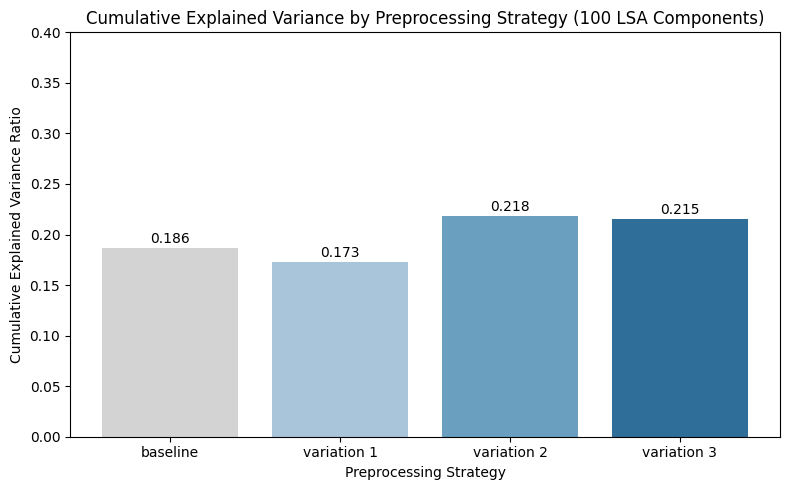

In [56]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    comparative["Title"],
    comparative["Variance Ratio"],
    color=["#d3d3d3", "#a8c5da", "#6a9fc0", "#2e6e99"]
)

ax.set_title("Cumulative Explained Variance by Preprocessing Strategy (100 LSA Components)")
ax.set_xlabel("Preprocessing Strategy")
ax.set_ylabel("Cumulative Explained Variance Ratio")
ax.set_ylim(0, 0.4)

for i, v in enumerate(comparative["Variance Ratio"]):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## Vocabulary Inspection: Examining which words were removed

Herein, I sample some of the words removed between different variations. I examine the "noise" words removed between two sets in particular to contrast what was removed between the approaches that were the most and least aggressive in preprocessing, and the ones whose resulting variance scores that differed the most (Variations I and II).

1. **Baseline** (*the least aggressive preprocessing*) & **Variation III** (*the most aggressive preprocessing*)

2. **Variation I** (*the lowest score*) & **Variation II** (*the highest score*)

### Baseline & Variation III

In [57]:
# Convert both vocabularies to a Python set, get_feature_names_out() extracts words
baseline_vocab = set(tfidf_vec.get_feature_names_out())
v3_vocab = set(tfidf_vec_v3.get_feature_names_out())

# Find words that appear in the baseline but not in Variation III using the set difference operator
difference_base_v3 = baseline_vocab - v3_vocab

# Display a random sample of 50 removed words
random.seed(42)
random.sample(list(difference_base_v3), 50)

['6722',
 'mcgregor',
 'doped',
 'we',
 '68hc811e2',
 'beckmans',
 'apoapsis',
 'videotext',
 'nosebleed',
 'lately',
 'rejects',
 'thaelmann',
 'rtf',
 'chemists',
 'colt',
 'smokestacks',
 '416',
 'harnessing',
 'scarcer',
 'cleveland',
 'cba',
 '2219',
 'vetted',
 'bode',
 'nokd',
 'encountered',
 'aubrey',
 'restroom',
 'resaon',
 'cull',
 'dts',
 'wnbc',
 'onion',
 'postulates',
 'marginal',
 'elective',
 'treaty',
 'originated',
 'megs',
 'niedemeyer',
 'possesion',
 '602',
 'massage',
 'anarchists',
 'deluding',
 '1815',
 '458',
 'nevermind',
 'tremaine',
 'christian']

In [58]:
# follow up, checking for lemmatized versions of words in variation 3

suspected_lemmas = ['originate', "metal", "dope", "anarchists"]
{word: word in v3_vocab for word in suspected_lemmas}

{'originate': False, 'metal': True, 'dope': False, 'anarchists': False}

### Variation I & Variation II

In this case we need to get both directions (i.e. words removed in Variation II but kept in Variation I and those removed in Variation I but kept in Variation II)

#### Variation I → Variation II

In [59]:
# Convert both vocabularies to a Python set, get_feature_names_out() extracts words
v1_vocab = set(tfidf_vec_v1.get_feature_names_out())
v2_vocab = set(tfidf_vec_v2.get_feature_names_out())

# Find words that appear in Variation I but not in Variation II using the set difference operator
difference_v1_v2 = v1_vocab - v2_vocab
# Find words that appear in Variation II but not in Variation I using the set difference operator
difference_v2_v1 = v2_vocab - v1_vocab

# Display a random sample of 50 removed words from Variation II
random.seed(42)
random.sample(list(difference_v1_v2), 50)

['rinkside',
 'res',
 'oneshot',
 'reinstated',
 'propertyowner',
 'grandfathered',
 'escapes',
 'miniskirt',
 'geode',
 'parasites',
 'muggers',
 'appended',
 'bozek',
 'neigborhoods',
 'carbide',
 'verticle',
 'planeten',
 'welcoming',
 'ils',
 'nodelist',
 'charger',
 'fpu',
 'opted',
 'beckman',
 'browne',
 'superintendent',
 'eqa',
 'hervey',
 'microphone',
 'colleague',
 'referendum',
 'loosing',
 'reaper',
 'freeways',
 'phenomena',
 'doe',
 'furnaces',
 'acquittals',
 'socsec',
 'rolls',
 'assigned',
 'cocksucker',
 'ymon',
 'balcony',
 'oxnard',
 'sens',
 'rehabilitation',
 'inventions',
 'triumphs',
 'eliminates']

#### Variation II → Variation I

In [60]:
# Display a random sample of 50 removed words from Variation I
random.seed(42)
random.sample(list(difference_v2_v1), 50)

['directly',
 'xc',
 '175',
 'legally',
 'afraid',
 'put',
 '650',
 '198',
 'tokyo',
 'billion',
 'inner',
 '1990',
 '40',
 'nine',
 'atlanta',
 'san',
 '429',
 'jtchern',
 'st',
 'hundred',
 'cleveland',
 'used',
 '85',
 'raw',
 'these',
 'comprehensive',
 'possibly',
 'overnight',
 'afterwards',
 'scientific',
 '_the',
 'daily',
 '201',
 '346',
 'tall',
 'minimal',
 'allegedly',
 'wild',
 'sas',
 '344',
 '902',
 '23',
 'recently',
 'several',
 'er',
 'neither',
 'dirty',
 'healthy',
 '230',
 'by']

## Vocabulary Inspection: What Preprocessing Approach Actually Removes

**Baseline - Variation III** demonstrates the that combined approach of applying tokenization + frequency pruning correctly removes the vast majority of non-domain specific noise: numbers, years, alphanumeric tokens, misspellings, and generic vocabulary with no topical specificity e.g. *6722, 416, 'lately', 'nokd', 'resaon','scarcer', 'restroom', 'marginal', 'nevermind', 'postulates', 'dts', 'harnessing'*, etc.

However, aggressive preprocessing also removes some genuinely domain-relevant vocabulary, e.g.
'Cleveland' is a city where the Cleveland Guardians (formerly Indians) baseball team plays, (Connor) 'McGregor' is a hockey player for the Edmonton Oilers (and widely regarded as the best player in the game), 'cba' most likely stands for 'collective bargaining agreement', something that is a very relevant topic to professional sports leagues i.e. Baseball (MLB) and Hockey (NHL), and the 'onion', which likely refers to 'The Onion' is a satirical newspaper, which is relevant to the domain of `POLITICS`

These are the unavoidable tradeoffs of rule-based preprocessing: broad filters that catch noise also occasionally strip relevant content.

**Variation I - Variation II** (words spaCy kept that frequency pruning removed) reveals the primary weakness of the spaCy-only approach: it retains rare tokens that pass the POS filter but appear in too few documents to be useful for topic modeling. This frequency-based pruning approach correctly removes non-domain specific tokens such as: *'ymon', 'socsec', 'ils', 'escapes','opted','reaper', 'balcony', 'triumphs', 'neigborhoods','furnaces', 'doe', *etc, whereas the tokenization based model allows such items to remain simply because they are either tagged as nouns, verbs, and alphabetical.

However, min_df=5 also removes genuinely domain-relevant but low-frequency terms such as: *'referendum'* (`POLITICS`), 'superintendent' (POLITICS), *'apoapsis'* (`SPACE`), *'sens'* (abbreviated but extremely common nickname for the *Ottowa Senators* - `HOCKEY`), *'thaelmann'* (german politician, thus clearly relevant to `POLITICS`).

This illustrates a fundamental tension in frequency-based pruning: the same threshold that removes noise also eliminates specialized vocabulary that appears rarely precisely because it is domain-specific.

**Variation II - Variation I** (words frequency pruning kept that spaCy removed) reveals the downside of strict POS filtering.

While the spaCy tokenization based approach in Variation I correctly removed numerous words that were not useful in determining any of the five target topics, e.g. non domain-specific adjectives or adverbs: *'overnight',  'daily', 'directly', 'afraid'*,  numbers: *175, 40, 429*, years: 1990, stopwords:  *'these', 'nine', 'used', 'by', 'hundred', nonsense* or one off context specific tokens: *'_the', 'jtchern'*, and acronyms: *'xc'*, some significant signal words were missed. Notably, the adjective *'scientific'* is a clear correlate of the space and electronics categories, while (as seen above) *'cleveland'* is a city where the baseball team the Cleveland Guardians play, and
*'atlanta'* is a city where the baseball team the Atlanta Braves plays.

Thus, by only allowing nouns and verbs, Variation I removes adjectives, adverbs and geographical location (GPE) that are relevant topic signals. This overly aggressive POS based-filtering likely explains why Variation I underperforms Variation II: it sacrifices discriminative vocabulary in the name of POS purity.

**Synthesized Analysis** Taken together, these comparisons explain what might be counterintuitive variance scores. Variation II outperforms Variation I (0.2186 vs 0.1732) due to the fact that  frequency pruning, while cruder linguistically, preserves more of the vocabulary which actually distinguishes topics — including adjectives, city names, and mid-frequency terms that spaCy discards simply because they are not nouns or verbs. The fact that Variation III (0.2155) barely improves on Variation II alone suggests that once frequency pruning has done its work, the additional constraints of POS filtering and lemmatization provide diminishing returns — and in some cases actively remove signal. A more targeted approach — adding PROPN to the POS filter in the tokenizer would likely yield better results in that function. Additionally, perhaps simply applying a more conservative tuning of the min_df and max_df parameters would improve upon either of the strategies as applied in their current form.

## Comparative Analysis: Variance Capture

Variation II captured the most variance (0.218), beating out Variation III by 0.003 for the highest score and Variation I (which had the lowest score, 0.173) by 0.045.

Thus, the approach that only pre-processed by removing words that appear too few (<5) and too many documents (>70%) performed better than all other approaches, including the approach combining that, with the tokenizer, which lemmatized all terms and removed all non-nouns and verbs, non-alphabetical and stopwords.

While one may assume that the more preprocessing the better, this result shows otherwise.

Thinking about it as a linguist, whereas lemmatization consolidates many forms of the same core meaning into one form and ensuring all tokens are alphabetical is likely an advantage for the tokenizer approach (as there are no strings of numbers as in the min/max-based approaches), the downside of this is that limiting the POS to just nouns and verbs is a counterproductive step, as there are many cases where, proper nouns (placenames and people), as well as adjectives and (occasionally adverbs) can be highly indicative of a specific topic.

Thus, the advantages of a process like lemmatization and limiting to alphabetical strings seems to be significantly outweighed by the disadvantage of restricting by POS given the fact that the worst score is Variation I, which is worse than the baseline (which does no preprocessing) and Variation II (the best) which only limits based on min/max frequency.

The vocabulary inspection below examines specific words removed by each approach, which will help to explain this result in more detail.


## Sparsity Analysis

Vocabulary pruning has a secondary benefit beyond variance capture, specifically, it reduces matrix sparsity, thus lowering memory usage and speeding up processing.

In [65]:
# Total elements per doc version
total_base = tfidf_df_base.shape[0] * tfidf_df_base.shape[1]
total_v1 = tfidf_vec_v1_df.shape[0] * tfidf_vec_v1_df.shape[1]
total_v2 = tfidf_vec_v2_df.shape[0] * tfidf_vec_v2_df.shape[1]
total_v3 = tfidf_vec_v3_df.shape[0] * tfidf_vec_v3_df.shape[1]

# Total non-zero (.nnz) elements per doc version
nonzero_base = tfidf_sparse_matrix.nnz
nonzero_v1 = tfidf_sparse_matrix_v1.nnz
nonzero_v2 = tfidf_sparse_matrix_v2.nnz
nonzero_v3 = tfidf_sparse_matrix_v3.nnz

# sparsity ratio per doc version
sparsity_ratio_base = (1 - nonzero_base/ total_base)
sparsity_ratio_v1 = (1 - nonzero_v1/ total_v1)
sparsity_ratio_v2 = (1 - nonzero_v2/ total_v2)
sparsity_ratio_v3 = (1 - nonzero_v3/ total_v3)


sparcity_analysis = pd.DataFrame(
    {"Doc": ["baseline", "variation 1", "variation 2", "variation 3"],
     "Total": [total_base, total_v1, total_v2, total_v3],
     "Vocab size": [tfidf_df_base.shape[1], tfidf_vec_v1_df.shape[1], tfidf_vec_v2_df.shape[1], tfidf_vec_v3_df.shape[1]],
     "Non-zero": [nonzero_base, nonzero_v1, nonzero_v2, nonzero_v3],
     "Sparsity ratio": [sparsity_ratio_base, sparsity_ratio_v1, sparsity_ratio_v2, sparsity_ratio_v3]
    }
)
sparcity_analysis

,Doc,Total,Vocab size,Non-zero,Sparsity ratio
0,baseline,84500586,29691,262821,0.996890
1,variation 1,51694744,18164,109944,0.997873
2,variation 2,19876464,6984,221870,0.988838
3,variation 3,12365870,4345,87710,0.992907


## Comparing Approaches: spaCy Preprocessing vs. TF-IDF Pruning

Variation I (spaCy tokenization only) produced a variance score of 0.1732, which was below even the baseline (0.1863), while Variation II (TF-IDF frequency pruning only) achieved the highest single-method score at 0.2186. This counterintuitive result in which a linguistically cruder approach outperformed a strict POS filtering is explained in detail in the vocabulary analysis above: spaCy's aggressive removal of adjectives, proper nouns, and mid-frequency terms strips genuinely discriminative vocabulary, while frequency pruning preserves it.

## Stopword Removal: spaCy List vs. max_df Frequency Threshold

To some degree both spaCy tokenizer and the min/max pruning approaches are likely removing some of the same words, namely the most frequently occurring stopwords (e.g.*'the', 'he', 'she', 'it', 'very', 'be'* (and forms thereof), *'have' *(and forms thereof), `'a'`, *'do'* (and forms thereof), etc.These forms, and numerous others from the Spacy English stopwords list (link below) surely occur in over 70% of documents, and are thus removed in both Variation 1 (via tokenizer) and Variation 2 (via min/max).

However, there are nonetheless some words in the Spacy stopwords which will most certainly not be caught by filtering out those occurring in  >70% of the documents, but which are nonetheless not at all useful in establishing topical similarity (e.g. *'these', 'used', 'by', 'nine', 'hundred'*, etc.). Without tokenizer removing the stopwords and POS's other than nouns and verbs, these vocabulary items remain in the Variant 2 vocabulary, because they likely appear in at least 5 documents and likely don't occur in over 70%.

This gap partly explains why Variation II outperforms Variation I — frequency pruning removes high-frequency noise but leaves mid-frequency stopwords intact, while spaCy's explicit list catches these, but at the same time also removes useful adjectives and proper nouns.

See [spaCy stopwords list here](https://github.com/explosion/spaCy/blob/master/spacy/lang/en/stop_words.py)

## The Curse of Dimensionality: Why Vocabulary Size Hurts Variance Capture

The curse of dimensionality says that the efficiency and effectiveness of algorithms diminish as the data dimensionality increases exponentially. Because data points become more sparse, and it becomes more difficult to identify patterns and relationships because of the amount of data required to adequately sample.

So given the size of the baseline dataset, which hasn't filtered out stopwords which provide no value, or filtered out the most rare or most frequently occurring words, that dataset is more clearly affected by the curse of dimensionality (as described above) than the other variations.